In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the Online Retail dataset
df = pd.read_csv("data/online_retail.csv", encoding="ISO-8859-1") 

print(df.head())
print(df.describe())

   index InvoiceNo StockCode                          Description  Quantity  \
0      0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1      1    536365     71053                  WHITE METAL LANTERN         6   
2      2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3      3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4      4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


/var/folders/c4/lp7tf77d1j5_vh5zsl8h57_h0000gn/T/ipykernel_76638/1999235158.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['MonthYear'] = df_cleaned['InvoiceDate'].dt.to_period('M')


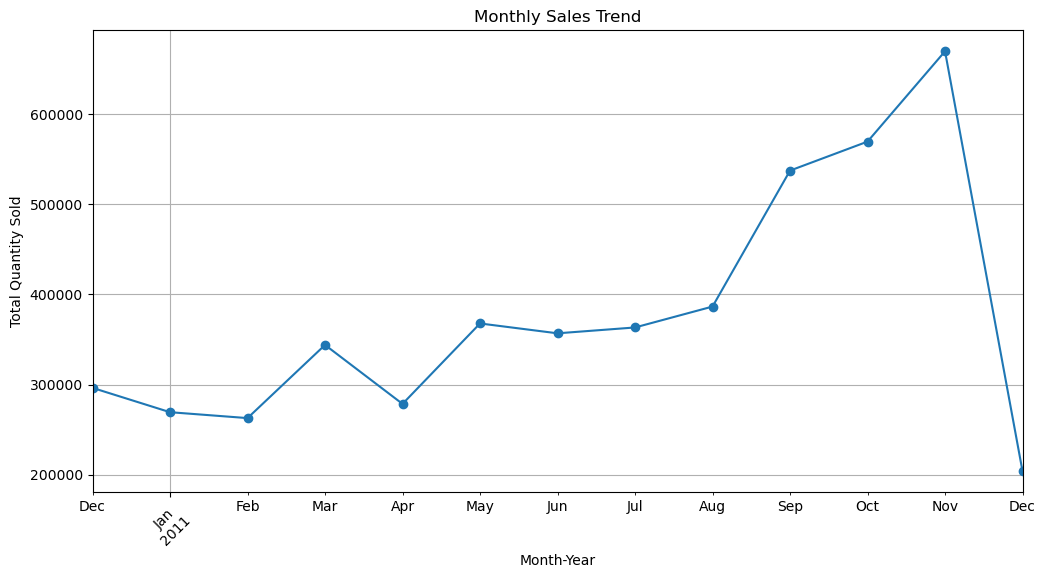

In [11]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove rows with missing CustomerID
df_cleaned = df.dropna(subset=['CustomerID'])

# Extract month-year for trend analysis
df_cleaned['MonthYear'] = df_cleaned['InvoiceDate'].dt.to_period('M')

# Aggregate sales per month
monthly_sales = df_cleaned.groupby('MonthYear')['Quantity'].sum()

# Plot the trend of monthly sales
plt.figure(figsize=(12, 6))
monthly_sales.plot(marker='o', linestyle='-')
plt.title('Monthly Sales Trend')
plt.xlabel('Month-Year')
plt.ylabel('Total Quantity Sold')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()




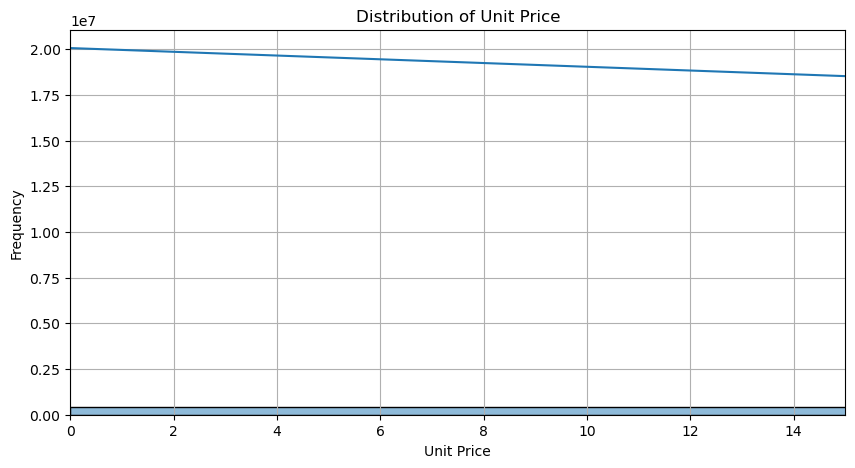

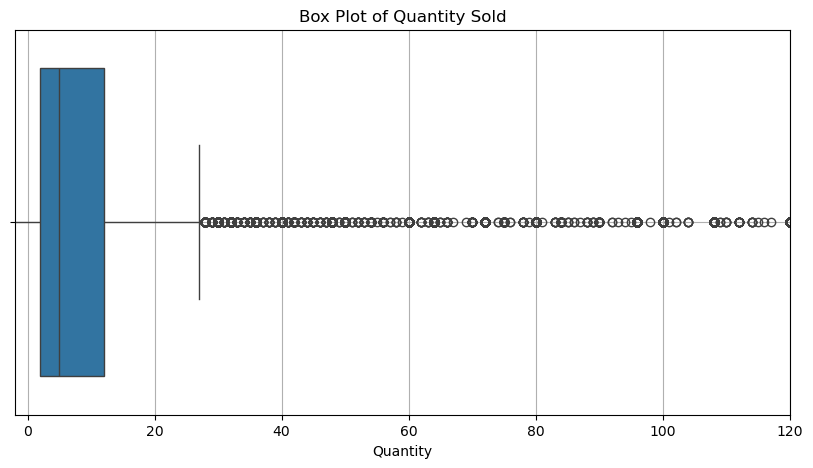

/var/folders/c4/lp7tf77d1j5_vh5zsl8h57_h0000gn/T/ipykernel_76638/1369485646.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


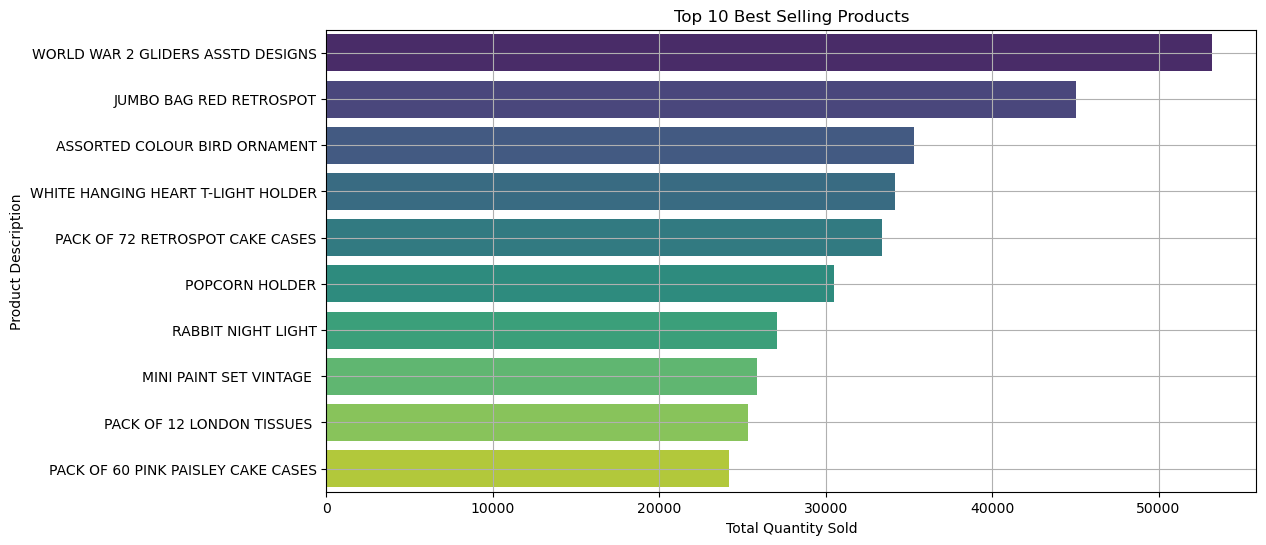

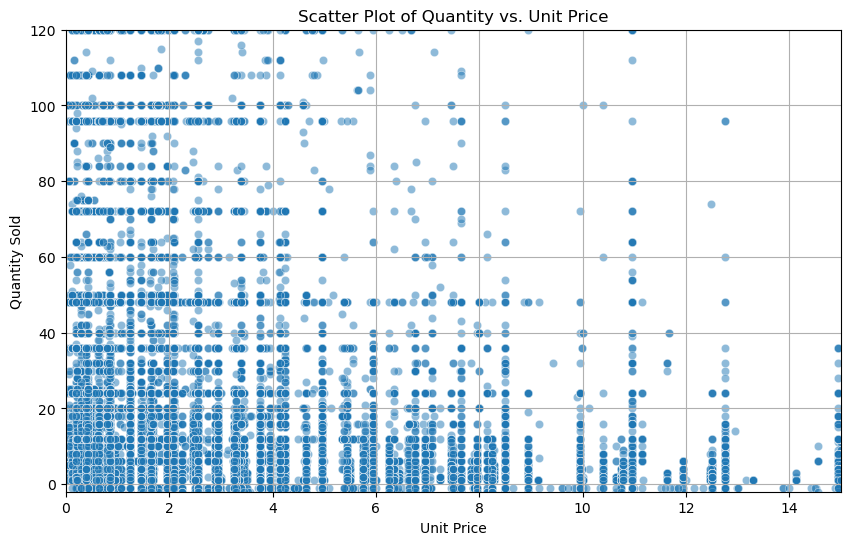

In [17]:
# Histogram for Unit Price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned['UnitPrice'], bins=50, kde=True)
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.xlim(0, df_cleaned['UnitPrice'].quantile(0.99))  # Remove outliers
plt.grid(True)
plt.show()

# Box plot for Quantity to detect outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_cleaned['Quantity'])
plt.title('Box Plot of Quantity Sold')
plt.xlabel('Quantity')
plt.xlim(df_cleaned['Quantity'].quantile(0.01), df_cleaned['Quantity'].quantile(0.99))  # Remove extreme outliers
plt.grid(True)
plt.show()

# Bar chart of top 10 selling products
top_products = df_cleaned.groupby('Description')['Quantity'].sum().nlargest(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.grid(True)
plt.show()

# Scatter plot for Quantity vs. Unit Price to see price impact on sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_cleaned['UnitPrice'], y=df_cleaned['Quantity'], alpha=0.5)
plt.title('Scatter Plot of Quantity vs. Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Quantity Sold')
plt.xlim(0, df_cleaned['UnitPrice'].quantile(0.99))  # Remove extreme values for better visualization
plt.ylim(df_cleaned['Quantity'].quantile(0.01), df_cleaned['Quantity'].quantile(0.99))  # Remove outliers
plt.grid(True)
plt.show()